In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("C:/Users/rasya/Desktop/ml_practice/crop recommendation/Crop_recommendation.csv")
df.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [5]:
df.shape

(2200, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [7]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

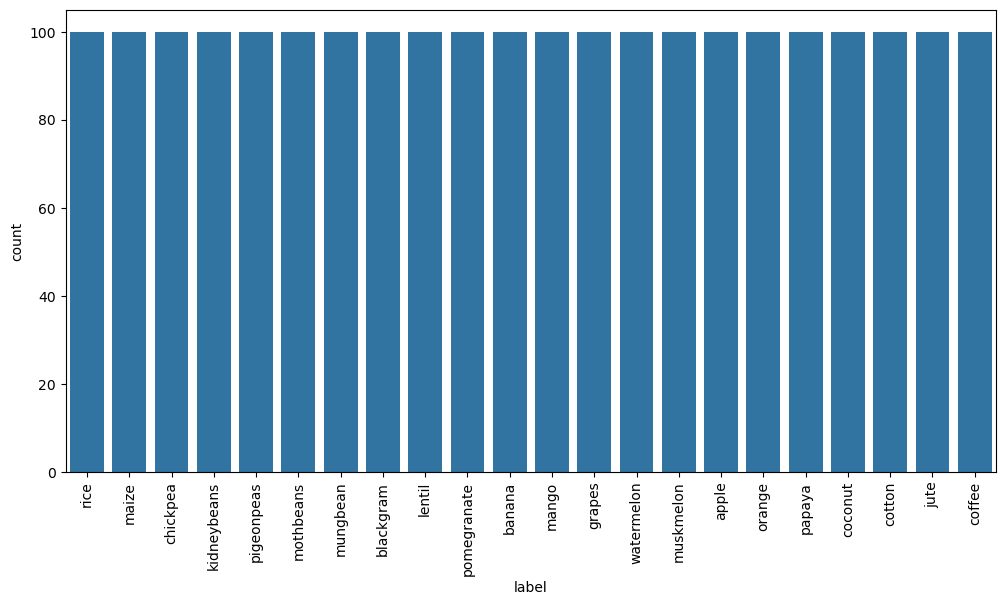

In [12]:
plt.figure(figsize=(12, 6))
sns.countplot(
    x = 'label',
    data = df
)

plt.xticks(rotation=90)
plt.show()

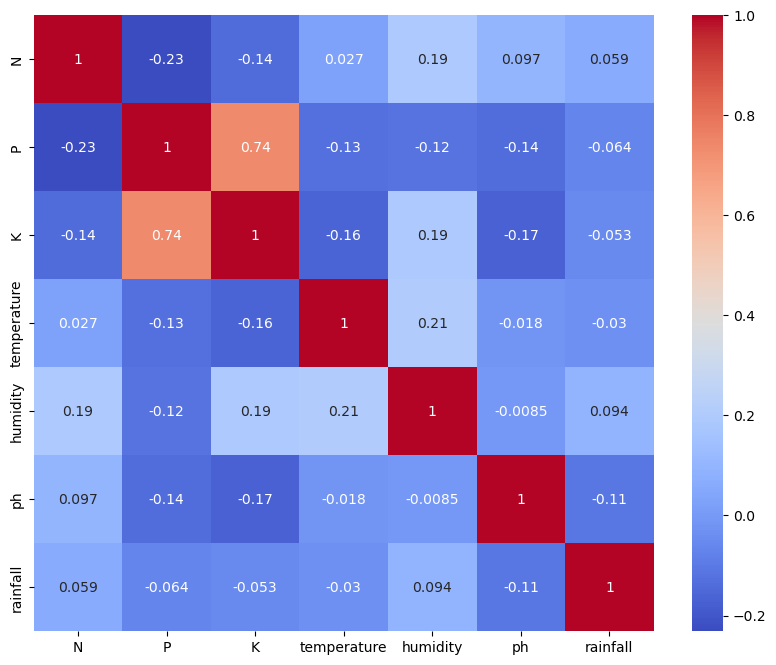

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop('label',axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

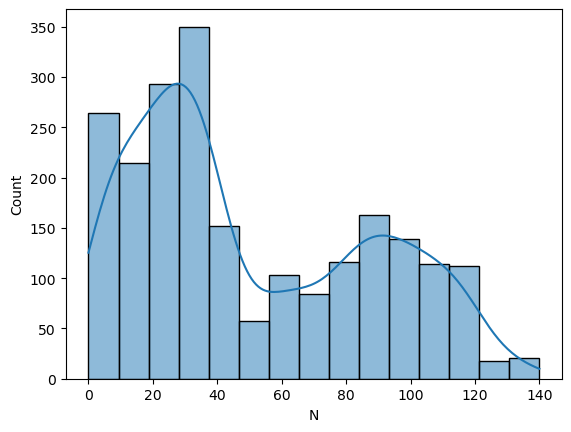

In [14]:
sns.histplot(df['N'], kde=True)

plt.show()

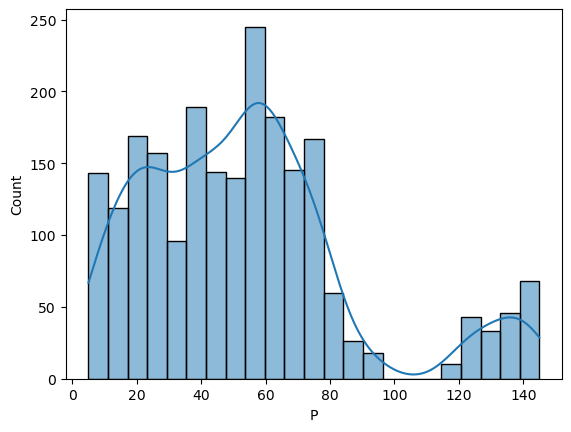

In [15]:
sns.histplot(df['P'], kde=True)

plt.show()

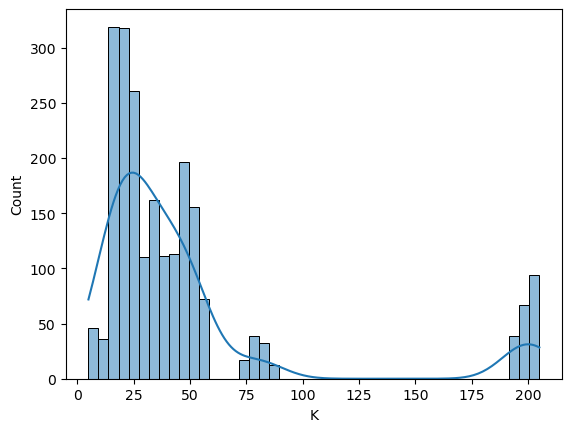

In [16]:
sns.histplot(df['K'], kde=True)

plt.show()

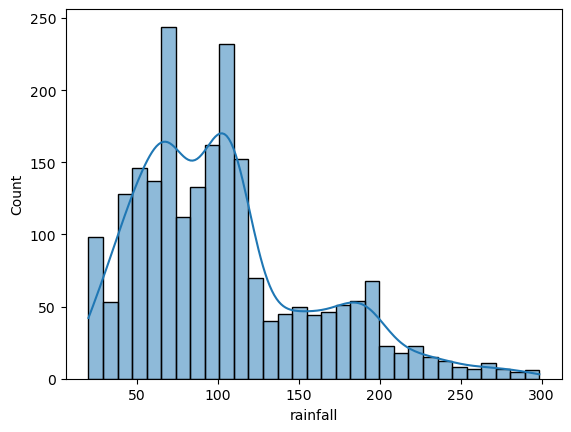

In [17]:
sns.histplot(df['rainfall'], kde=True)

plt.show()

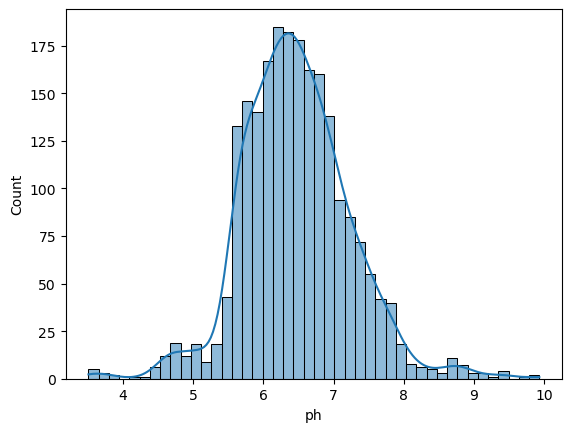

In [18]:
sns.histplot(df['ph'], kde=True)

plt.show()

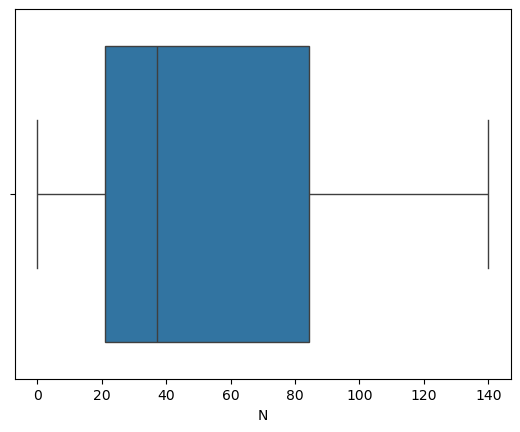

In [19]:
sns.boxplot(x=df['N'])

plt.show()

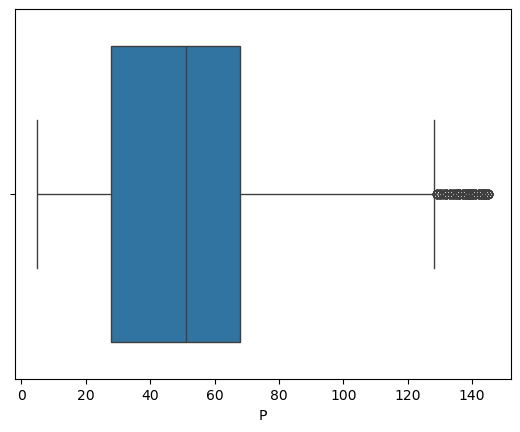

In [20]:
sns.boxplot(x=df['P'])

plt.show()

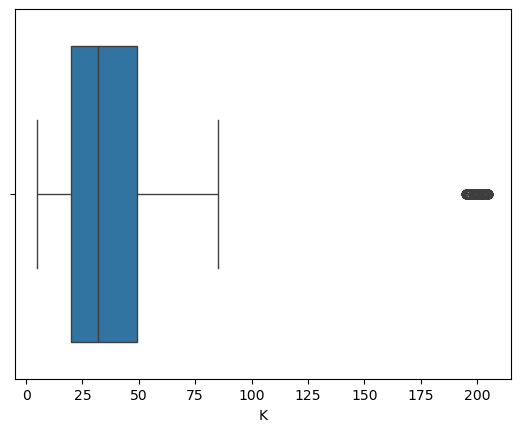

In [21]:
sns.boxplot(x=df['K'])

plt.show()

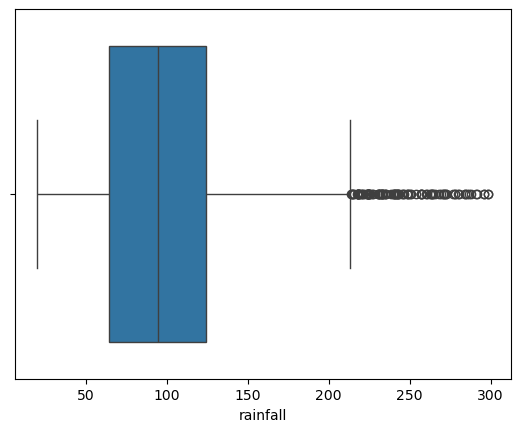

In [22]:
sns.boxplot(x=df['rainfall'])

plt.show()

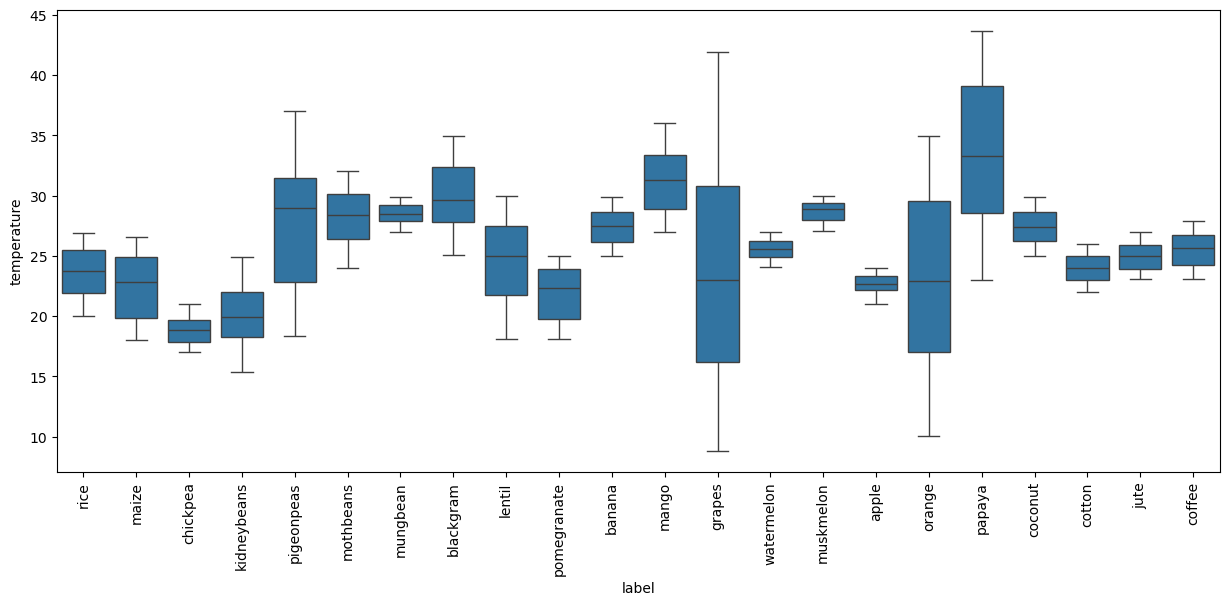

In [23]:
plt.figure(figsize=(15,6))

sns.boxplot(
    x='label',
    y='temperature',
    data=df
)

plt.xticks(rotation=90)

plt.show()

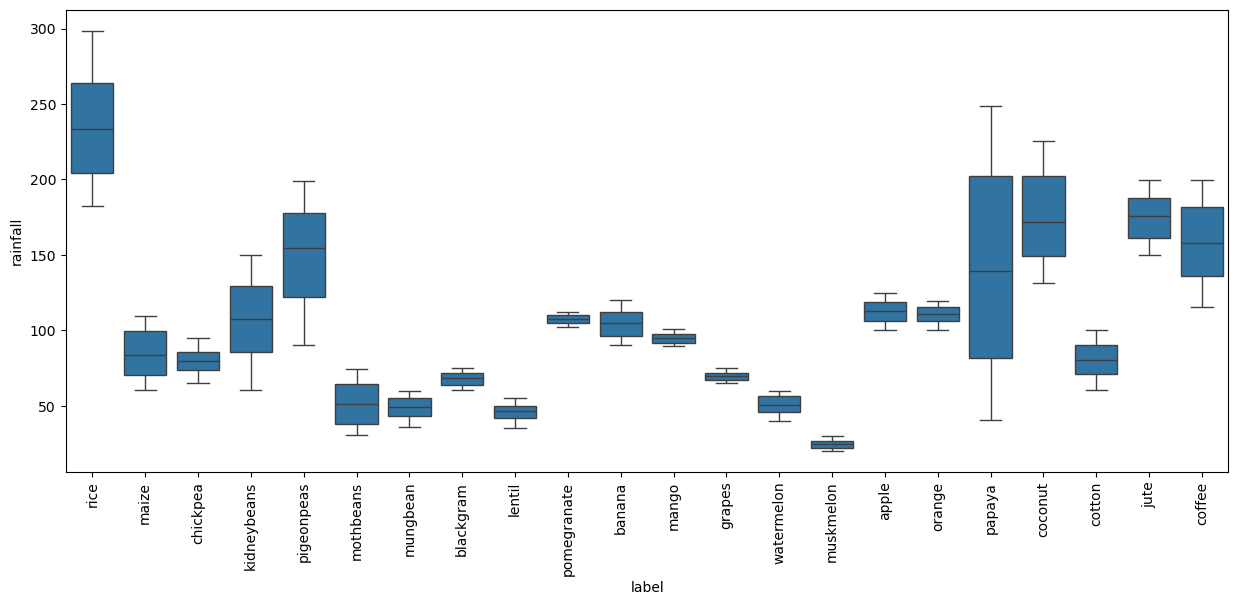

In [24]:
plt.figure(figsize=(15,6))

sns.boxplot(
    x='label',
    y='rainfall',
    data=df
)

plt.xticks(rotation=90)

plt.show()

In [25]:
# divide data and target
x = df.drop('label', axis = 1)
y = df['label']

In [26]:
# Label encoding for labels column

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)
print(y[:10])

['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']
[20 20 20 20 20 20 20 20 20 20]


In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2, stratify=y)

In [28]:
print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

(1760, 7)
(440, 7)
(1760,)
(440,)


In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [30]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
y_pred_dt = dt.predict(x_test)

from sklearn.metrics import accuracy_score
print('Accuracy:')
print(accuracy_score(y_test, y_pred_dt))

from sklearn.metrics import classification_report
print('Classification Report: ')
print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

from sklearn.metrics import confusion_matrix
print('Confusion matrix: ')
cm = confusion_matrix(
    y_test,
    y_pred_dt
)
print(cm)

Accuracy:
0.9795454545454545
Classification Report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.80      0.89        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      0.95      0.95        20
           9       1.00      1.00      1.00        20
          10       0.86      0.90      0.88        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.86      0.95      0.90        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00     

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
y_pred_rf = rf.predict(x_test)

from sklearn.metrics import accuracy_score
print('Accuracy: ')
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)
print(rf_accuracy)

from sklearn.metrics import classification_report
print('classification report: ')
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

feature_importances = rf.feature_importances_
print('Feature importances: ')
for feature, importance in zip(
    x.columns,
    feature_importances
):
    print(feature, importance)

Accuracy: 
0.9954545454545455
classification report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00    

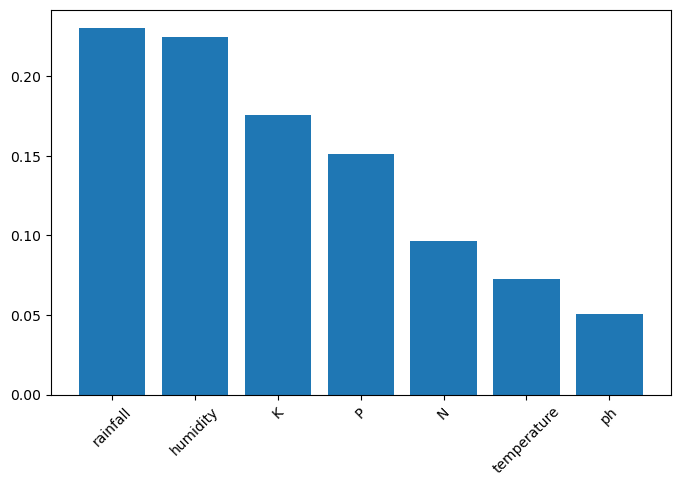

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)

plt.show()

In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb.fit(x_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
y_pred_xgb = xgb.predict(x_test)

from sklearn.metrics import accuracy_score
print('Accuracy: ')
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)
print(xgb_accuracy)

from sklearn.metrics import classification_report
print('classification report: ')
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

print('Feature importances: ')
for feature, importance in zip(
    x.columns,
    xgb.feature_importances_
):
    print(feature, importance)

Accuracy: 
0.9886363636363636
classification report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      0.85      0.92        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       0.91      1.00      0.95        20
          15       1.00      1.00      1.00        20
          16       1.00    

In [37]:
import pickle

pickle.dump(
    rf,
    open("crop_model.pkl","wb")
)

In [38]:
pickle.dump(
    le,
    open("label_encoder.pkl","wb")
)

In [39]:
model = pickle.load(
    open("crop_model.pkl","rb")
)

encoder = pickle.load(
    open("label_encoder.pkl","rb")
)

In [40]:
sample = [[90,42,43,20.8,82.0,6.5,202]]

prediction = model.predict(sample)

crop = encoder.inverse_transform(prediction)

print(crop)

['rice']


c:\Users\rasya\anaconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[None,10,20,30],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [42]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
0.9960227272727271


In [43]:
best_rf = grid.best_estimator_

In [44]:
import pickle

pickle.dump(best_rf,
            open("crop_model.pkl","wb"))

pickle.dump(le,
            open("label_encoder.pkl","wb"))

In [45]:
import pickle

model = pickle.load(
    open("crop_model.pkl", "rb")
)

encoder = pickle.load(
    open("label_encoder.pkl", "rb")
)

In [46]:
sample = [[90,42,43,20.8,82.0,6.5,202]]

prediction = model.predict(sample)

crop = encoder.inverse_transform(prediction)

print(crop)

['rice']


c:\Users\rasya\anaconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [48]:
samples = [[[90,42,43,20.8,82.0,6.5,202]], [[20,30,40,25,60,6.8,80]], [[100,50,50,30,90,6.5,250]]]

for sample in samples:
    prediction = model.predict(sample)
    crop = encoder.inverse_transform(prediction)
    print(crop)

['rice']
['mango']
['papaya']


c:\Users\rasya\anaconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\rasya\anaconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\rasya\anaconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
